In [1]:
import torch
from argparse import Namespace
from ay2.tools.text._phonemes import Phonemer_Tokenizer_Recombination
from pandas import Series

torch.serialization.add_safe_globals([
    Namespace,
    Phonemer_Tokenizer_Recombination,
    Series,
])


/lambda/nfs/algovirginia/workspace/DeepfakeDetectionRenewed/venv/lib/python3.10/site-packages/librosa/core/intervals.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/lambda/nfs/algovirginia/workspace/DeepfakeDetectionRenewed/venv/lib/python3.10/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/lambda/nfs/algovirginia/workspace/DeepfakeDetectionRenewed/venv/lib/python3.10/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._r

In [2]:
import torch

# Monkey-patch torch.load to default to weights_only=False (Torch 2.6+ defaults to True)
_orig_torch_load = torch.load

def _torch_load_no_weights_only(*args, **kwargs):
    kwargs.setdefault("weights_only", False)
    return _orig_torch_load(*args, **kwargs)

torch.load = _torch_load_no_weights_only
print("✅ Patched torch.load to default weights_only=False for this kernel session.")


✅ Patched torch.load to default weights_only=False for this kernel session.


In [3]:
import wandb, random

run = wandb.init(
    entity="krishrawat0222-f",  # 👈 replace with your wandb username or team name
    project="DeepfakeDetectionRenewed",
    config={
        "test_run": True,
        "learning_rate": 0.02,
        "architecture": "CNN",
        "dataset": "dummy",
        "epochs": 10,
    },
)

for epoch in range(10):
    acc = 1 - 2**-epoch - random.random() / epoch if epoch > 0 else 0.1
    loss = 2**-epoch + random.random() / (epoch + 1)
    run.log({"acc": acc, "loss": loss})

run.finish()


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/ubuntu/.netrc.
wandb: Currently logged in as: yashaspatil (krishrawat0222-f) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [huggingface_hub.inference] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


acc,▁▁▆▆▆▇▇███
loss,█▃▃▂▁▁▁▁▁▁
acc,0.90899
loss,0.05356


## Phoneme Recognition Model

In [4]:
import os, sys
# Add the directory containing the notebook to sys.path
notebook_dir = os.getcwd()
if notebook_dir not in sys.path:
    sys.path.insert(0, notebook_dir)

In [5]:
from phoneme_GAT.phoneme_model import BaseModule, load_phoneme_model, optim_param

/lambda/nfs/algovirginia/workspace/DeepfakeDetectionRenewed/venv/lib/python3.10/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [6]:
from ay2.tools.text._phonemes import Phonemer_Tokenizer_Recombination

1. You can download the pretrained phoneme recognition model in [google drive](https://drive.google.com/file/d/1SbqynkUQxxlhazklZz9OgcVK7Fl2aT-z/view?usp=drive_link).
2. Change `pretrained_path` to you own custom path.
3. Remember to change the `pretrained_path` and `vocab_path` in the `load_phoneme_model` function of `phoneme_GAT.phoneme_model`.

In [7]:
network_param = Namespace(
    network_name="WavLM",
    pretrained_path="pretrained/best-epoch=42-val-per=0.407000.ckpt",
    pretrained_name="microsoft/wavlm-base",   # ✅ add this
    freeze=True,
    freeze_transformer=True,
    eos_token="</s>",
    bos_token="<s>",
    unk_token="<unk>",
    pad_token="<pad>",
    word_delimiter_token="|",
    vocab_size=200,
)


To build the phoneme recognition model,
1. you must specify the pretrained_path!!!! Please download the provided pretrained phoneme model; or you can train yourself model through `train_phoneme_model.py`.
2. in the `load_phoneme_model` function, you have to change the correct `vocab_path`

In [8]:
from phoneme_GAT.phoneme_model import BaseModule, load_phoneme_model, optim_param

total_num_phonemes = 687  ## 198, or 687

phoneme_model = load_phoneme_model(
    network_name=network_param.network_name,
    pretrained_path=network_param.pretrained_path,
    total_num_phonemes=total_num_phonemes,
)
assert len(phoneme_model.tokenizer.total_phonemes) == total_num_phonemes

Now, load vocab json files from /lambda/nfs/algovirginia/workspace/DeepfakeDetectionRenewed/vocab_phoneme Please make sure the vocab files are correct
Load WavLM model!!!!!!!


Some weights of WavLMForCTC were not initialized from the model checkpoint at microsoft/wavlm-base and are newly initialized: ['lm_head.weight', 'lm_head.bias', 'encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


torch.Size([687, 768])


# Load model

## Audio model

In [9]:
from phoneme_GAT.modules import Phoneme_GAT_lit,Phoneme_GAT

In [10]:
audio_model = Phoneme_GAT(
    backbone='wavlm',
    use_raw=0,
    use_GAT=1,
    n_edges=10,
)

Now, load vocab json files from /lambda/nfs/algovirginia/workspace/DeepfakeDetectionRenewed/vocab_phoneme Please make sure the vocab files are correct
Load WavLM model!!!!!!!


Some weights of WavLMForCTC were not initialized from the model checkpoint at microsoft/wavlm-base and are newly initialized: ['lm_head.weight', 'lm_head.bias', 'encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


torch.Size([687, 768])


Generate a random audio to test the model.

In [11]:
import os

# ----------------------------
# Load HF token from secret.txt
# ----------------------------
def load_hf_token(path="secret.txt"):
    if os.path.exists(path):
        with open(path, "r") as f:
            return f.read().strip()
    return None

DATASET_NAME   = "Bisher/ASVspoof_2019_LA"
CACHE_DIR      = "./data/asvspoof_2019_la"
SUBSET_SAMPLES = None

HF_TOKEN = load_hf_token()  # 🔥 auto-loads from secret.txt

print("Dataset name    :", DATASET_NAME)
print("Cache dir       :", CACHE_DIR)
print("Subset samples  :", SUBSET_SAMPLES)
print("HF token present:", "✅ Yes" if HF_TOKEN else "❌ No (use secret.txt or HF login)")


Dataset name    : Bisher/ASVspoof_2019_LA
Cache dir       : ./data/asvspoof_2019_la
Subset samples  : None
HF token present: ✅ Yes


In [12]:
from datasets import load_dataset, Audio
from collections import Counter

print("=" * 80)
print("Downloading ASVspoof 2019 LA to cache (once) and verifying decoding…")
print("=" * 80)

# Use HF TEST split as the pool we'll train from (since it's bigger)
hf_train_pool = load_dataset(
    DATASET_NAME,          # e.g. "LanceaKing/asvspoof2019"
    split="test",
    cache_dir=CACHE_DIR,
    token=HF_TOKEN if HF_TOKEN else None,
)

print("Columns in HF split:", hf_train_pool.column_names)
print("Features:", hf_train_pool.features)

# Ensure audio comes out at 16 kHz (consistent with model)
hf_train_pool = hf_train_pool.cast_column("audio", Audio(sampling_rate=16000))

# Handle the case where SUBSET_SAMPLES can be None
if SUBSET_SAMPLES is None:
    subset_size = len(hf_train_pool)
else:
    subset_size = min(SUBSET_SAMPLES, len(hf_train_pool))

hf_train_small = hf_train_pool.shuffle(seed=42).select(range(subset_size))

print(f"✓ Cached under: {CACHE_DIR}")
print(f"✓ HF TEST split size (train pool): {len(hf_train_pool)} | (subset): {len(hf_train_small)}")

# Inspect first sample keys & audio metadata
s0 = hf_train_small[0]
print("\nFirst sample keys:", list(s0.keys()))
a0 = s0["audio"]
print("Audio fields present:", list(a0.keys()))
print("Audio sampling_rate:", a0.get("sampling_rate"))
print(
    "Audio array dtype/len:",
    type(a0.get("array")).__name__,
    len(a0.get("array")) if a0.get("array") is not None else None,
)

# ----- Label / key inspection (robust) -----

# Decide which column we should treat as the label-ish thing
label_col = None
for cand in ["label", "key", "class", "target"]:
    if cand in hf_train_small.column_names:
        label_col = cand
        break

if label_col is None:
    print("\n[WARN] No obvious label column found; available columns:", hf_train_small.column_names)
else:
    print(f"\nUsing '{label_col}' as label-like column for sanity check.")
    raw_vals = [ex[label_col] for ex in hf_train_small]
    print(f"Raw '{label_col}' value counts:", Counter(raw_vals))

    # Try to map to numeric 0/1 for convenience, but handle both strings and ints
    key_to_int = {"bonafide": 0, "spoof": 1, "real": 0, "fake": 1}

    numeric_labels = []
    for v in raw_vals:
        if isinstance(v, int):
            numeric_labels.append(v)
        elif isinstance(v, str):
            if v in key_to_int:
                numeric_labels.append(key_to_int[v])
            else:
                # fallback: hash to 0/1 just so Counter works
                numeric_labels.append(hash(v) % 2)
        else:
            # weird type, just cast to int if possible
            try:
                numeric_labels.append(int(v))
            except Exception:
                numeric_labels.append(0)

    print("Numeric label counts (best-effort 0/1 mapping):", Counter(numeric_labels))

print("=" * 80)


Columns in HF split: ['speaker_id', 'audio_file_name', 'audio', 'system_id', 'key']
Features: {'speaker_id': Value(dtype='string', id=None), 'audio_file_name': Value(dtype='string', id=None), 'audio': Audio(sampling_rate=16000, mono=True, decode=True, id=None), 'system_id': Value(dtype='string', id=None), 'key': ClassLabel(names=['bonafide', 'spoof'], id=None)}
✓ Cached under: ./data/asvspoof_2019_la
✓ HF TEST split size (train pool): 71237 | (subset): 71237

First sample keys: ['speaker_id', 'audio_file_name', 'audio', 'system_id', 'key']
Audio fields present: ['path', 'array', 'sampling_rate']
Audio sampling_rate: 16000
Audio array dtype/len: ndarray 26536

Using 'key' as label-like column for sanity check.
Raw 'key' value counts: Counter({1: 63882, 0: 7355})
Numeric label counts (best-effort 0/1 mapping): Counter({1: 63882, 0: 7355})


In [13]:
from loader import get_dataloader, get_train_dataloader, get_eval_dataloader

val_dataloader = get_eval_dataloader(
    source="hf",
    split="validation",
    hf_name=DATASET_NAME,
    batch_size=20,
    hf_cache_dir=CACHE_DIR,
    limit=3000,
    hf_token=HF_TOKEN if HF_TOKEN else None,
)

/lambda/nfs/algovirginia/workspace/DeepfakeDetectionRenewed/loader.py:18: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  torchaudio.set_audio_backend("sox_io")


✓ HF Bisher/ASVspoof_2019_LA:validation [eval] → 3000 samples (balance=True)


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# AUGMENTATION ATTACK SUITE  ·  Run ONE augmentation at a time + audition 10 clips
# ─────────────────────────────────────────────────────────────────────────────
import random, torch, numpy as np, math
import IPython.display as ipd
from IPython.display import display
import torchaudio
import torchaudio.functional as F
from fractions import Fraction

SAMPLE_RATE = 16_000
LISTEN_N    = 10
SEED        = 42
random.seed(SEED); torch.manual_seed(SEED); np.random.seed(SEED)

# ── ✏️  CHANGE THESE ─────────────────────────────────────────────────────────
ACTIVE_AUG = "reverberation"
# Options:
#   "pitch_up"        – pitch shift up N semitones
#   "pitch_down"      – pitch shift down N semitones
#   "phase_noise"     – small random phase perturbation
#   "amp_scale"       – fixed amplitude multiplier
#   "volume"          – gain in dB
#   "additive_noise"  – white noise at target SNR (dB)
#   "time_stretch"    – speed up/down without pitch change
#   "lowpass"         – low-pass filter at cutoff Hz
#   "highpass"        – high-pass filter at cutoff Hz
#   "reverberation"   – simulated room reverb
#   "codec_mulaw"     – mu-law 8-bit telephone codec

AUG_PARAMS = {
    "pitch_up":       {"semitones": 2},
    "pitch_down":     {"semitones": 2},
    "phase_noise":    {"noise_level": 0.012},
    "amp_scale":      {"scale": 1.20},
    "volume":         {"gain_db": 4.0},
    "additive_noise": {"snr_db": 32},
    "time_stretch":   {"rate": 1.07},
    "lowpass":        {"cutoff_hz": 6500},
    "highpass":       {"cutoff_hz": 120},
    "reverberation":  {"t60": 0.6, "room_scale": 0.5},
    "codec_mulaw":    {},
}
# ─────────────────────────────────────────────────────────────────────────────

def _match_length(x, target_len):
    if x.shape[-1] < target_len:
        x = torch.nn.functional.pad(x, (0, target_len - x.shape[-1]))
    return x[..., :target_len]

def aug_pitch_up(wav, semitones):
    factor = 2 ** (semitones / 12)
    frac   = Fraction(factor).limit_denominator(20)
    stretched = F.resample(wav, frac.numerator, frac.denominator)
    return _match_length(stretched, wav.shape[-1])

def aug_pitch_down(wav, semitones):
    factor = 2 ** (-semitones / 12)
    frac   = Fraction(factor).limit_denominator(20)
    stretched = F.resample(wav, frac.numerator, frac.denominator)
    return _match_length(stretched, wav.shape[-1])

def aug_phase_noise(wav, noise_level):
    spec  = torch.fft.rfft(wav)
    phase = torch.angle(spec)
    mag   = torch.abs(spec)
    phase = phase + torch.randn_like(phase) * noise_level * torch.pi
    return torch.fft.irfft(mag * torch.exp(1j * phase), n=wav.shape[-1])

def aug_amp_scale(wav, scale):
    return wav * scale

def aug_volume(wav, gain_db):
    gain = 10 ** (gain_db / 20)
    return wav * gain

def aug_additive_noise(wav, snr_db):
    sig_power   = wav.pow(2).mean()
    noise       = torch.randn_like(wav)
    noise_power = noise.pow(2).mean()
    scale       = (sig_power / (noise_power * 10 ** (snr_db / 10))).sqrt()
    return wav + scale * noise

def aug_time_stretch(wav, rate):
    orig_len = wav.shape[-1]
    frac     = Fraction(rate).limit_denominator(20)
    stretched = F.resample(wav, frac.numerator, frac.denominator)
    return _match_length(stretched, orig_len)

def aug_lowpass(wav, cutoff_hz):
    return F.lowpass_biquad(wav, SAMPLE_RATE, cutoff_freq=cutoff_hz)

def aug_highpass(wav, cutoff_hz):
    return F.highpass_biquad(wav, SAMPLE_RATE, cutoff_freq=cutoff_hz)

def aug_reverberation(wav, t60=0.6, room_scale=0.5):
    B, C, T = wav.shape
    rir_len = min(int(t60 * SAMPLE_RATE), 1600)
    t       = torch.linspace(0, t60, rir_len, device=wav.device)
    decay   = torch.exp(-6.9 * t / t60)
    rir     = torch.randn(rir_len, device=wav.device) * decay

    for delay_ms in [15, 30, 50]:
        d = int(delay_ms * 1e-3 * SAMPLE_RATE * room_scale)
        if d < rir_len:
            rir[d] += 0.4 * room_scale * decay[d]

    rir   = rir / (rir.abs().max() + 1e-8)
    n_fft = 2 ** math.ceil(math.log2(T + rir_len - 1))
    wav_f = torch.fft.rfft(wav, n=n_fft)
    rir_f = torch.fft.rfft(rir, n=n_fft)
    out   = torch.fft.irfft(wav_f * rir_f, n=n_fft)
    return out[..., :T]

def aug_codec_mulaw(wav):
    wav8    = F.resample(wav, SAMPLE_RATE, 8000)
    encoded = torchaudio.functional.mu_law_encoding(wav8, quantization_channels=256)
    decoded = torchaudio.functional.mu_law_decoding(encoded, quantization_channels=256)
    wav16   = F.resample(decoded, 8000, SAMPLE_RATE)
    return _match_length(wav16, wav.shape[-1])

# ─────────────────────────────────────────────────────────────────────────────

AUGMENTATIONS = {
    "pitch_up":       lambda w: aug_pitch_up(w,        **AUG_PARAMS["pitch_up"]),
    "pitch_down":     lambda w: aug_pitch_down(w,      **AUG_PARAMS["pitch_down"]),
    "phase_noise":    lambda w: aug_phase_noise(w,     **AUG_PARAMS["phase_noise"]),
    "amp_scale":      lambda w: aug_amp_scale(w,       **AUG_PARAMS["amp_scale"]),
    "volume":         lambda w: aug_volume(w,          **AUG_PARAMS["volume"]),
    "additive_noise": lambda w: aug_additive_noise(w,  **AUG_PARAMS["additive_noise"]),
    "time_stretch":   lambda w: aug_time_stretch(w,    **AUG_PARAMS["time_stretch"]),
    "lowpass":        lambda w: aug_lowpass(w,         **AUG_PARAMS["lowpass"]),
    "highpass":       lambda w: aug_highpass(w,        **AUG_PARAMS["highpass"]),
    "reverberation":  lambda w: aug_reverberation(w,   **AUG_PARAMS["reverberation"]),
    "codec_mulaw":    lambda w: aug_codec_mulaw(w),
}

assert ACTIVE_AUG in AUGMENTATIONS, \
    f"Unknown augmentation '{ACTIVE_AUG}'. Choose from: {list(AUGMENTATIONS.keys())}"

aug_fn        = AUGMENTATIONS[ACTIVE_AUG]
active_params = AUG_PARAMS[ACTIVE_AUG]

# ── Run selected augmentation over full val dataloader ───────────────────────
chunks = []
print(f"Running augmentation: '{ACTIVE_AUG}' | params: {active_params}\n")

for batch_idx, batch in enumerate(val_dataloader):
    wav = batch["audio"]
    if wav.dim() == 2:
        wav = wav.unsqueeze(1)

    try:
        chunks.append(aug_fn(wav.clone()).cpu())
    except Exception as e:
        print(f"  [WARN] batch {batch_idx} failed: {e}")

    if (batch_idx + 1) % 10 == 0:
        print(f"  processed ~{(batch_idx + 1) * val_dataloader.batch_size} samples …")

# Concat
if not chunks:
    raise ValueError("No augmented batches were produced; check warnings above.")

max_len = max(c.shape[-1] for c in chunks)
aug_tensor = torch.cat(
    [torch.nn.functional.pad(c, (0, max_len - c.shape[-1])) for c in chunks], dim=0
)
print(f"\n✅  '{ACTIVE_AUG}' {active_params}  →  tensor shape: {aug_tensor.shape}")

# ── Audition 10 random clips ─────────────────────────────────────────────────
listen_idx = random.sample(range(aug_tensor.shape[0]), min(LISTEN_N, aug_tensor.shape[0]))
print(f"\n🎧  {len(listen_idx)} random clips  ──  {ACTIVE_AUG} {active_params}\n{'─'*50}")

for rank, idx in enumerate(listen_idx, 1):
    wav_np = aug_tensor[idx, 0].numpy().astype(np.float32)
    peak   = np.abs(wav_np).max()
    if peak > 0:
        wav_np /= peak
    print(f"  clip {rank:>2d}  (val idx {idx})")
    display(ipd.Audio(wav_np, rate=SAMPLE_RATE, normalize=False))

Running augmentation: 'reverberation' | params: {'t60': 0.6, 'room_scale': 0.5}

  processed ~200 samples …
  processed ~400 samples …
  processed ~600 samples …
  processed ~800 samples …
  processed ~1000 samples …
  processed ~1200 samples …
  processed ~1400 samples …
  processed ~1600 samples …
  processed ~1800 samples …
  processed ~2000 samples …
  processed ~2200 samples …
  processed ~2400 samples …
  processed ~2600 samples …
  processed ~2800 samples …
  processed ~3000 samples …

✅  'reverberation' {'t60': 0.6, 'room_scale': 0.5}  →  tensor shape: torch.Size([3000, 1, 48000])

🎧  10 random clips  ──  reverberation {'t60': 0.6, 'room_scale': 0.5}
──────────────────────────────────────────────────
  clip  1  (val idx 2619)


  clip  2  (val idx 456)


  clip  3  (val idx 102)


  clip  4  (val idx 1126)


  clip  5  (val idx 1003)


  clip  6  (val idx 914)


  clip  7  (val idx 571)


  clip  8  (val idx 419)


  clip  9  (val idx 2771)


  clip 10  (val idx 2233)


# Lit model

The settings of the `AudioModel` are defined in the `cfg`. Each setting is a key-value pair, where the key is the name of the setting and the value is the value of the setting. The meaning of each setting is defined as follows:

1. **Network Structure Parameters**:
   - `backbone` : "wavlm", the backbone of the phoneme recognition model.
   - `use_raw` : `False`, whether to use raw transformer as the backbone
   - `use_GAT`: `True`, whether to use GAT
   - `n_edges`: `10`, the nubmer of edges for each node in the GAT
   - `use_pool`: `True`, whether to use pooling


2. **Loss Function Parameters**:
   - `use_clip`: `True`, whether to use clip loss


3. **Data Augmentation and Training Strategy**:
   - `use_aug`: `True`, whether to use data augmentation in the training


In [15]:
from argparse import Namespace

# Construct the configuration using Namespace
cfg = Namespace(
    PhonemeGAT=Namespace(
        backbone="wavlm",  # wavlm or wav2vec
        use_raw=False,              # whether to use raw transformer as the backbone
        use_GAT=True,              # whether to use GAT
        n_edges=10,                # the nubmer of edges for each node in the GAT
        use_aug=True,              # whether to use data augmentation in the training
        use_pool=True,            # whether to use pooling
        use_clip=True,             # whether to use clip loss
    )
)

In [16]:
from pytorch_lightning import Trainer, LightningModule
from pytorch_lightning.loggers import  CSVLogger

We use the pytorch Lightning module to train the model, where we define the train step, validation/predict step, loss function and optimizer.

In [17]:
audio_model_lit = Phoneme_GAT_lit(cfg=cfg)

Now, load vocab json files from /lambda/nfs/algovirginia/workspace/DeepfakeDetectionRenewed/vocab_phoneme Please make sure the vocab files are correct
Load WavLM model!!!!!!!


Some weights of WavLMForCTC were not initialized from the model checkpoint at microsoft/wavlm-base and are newly initialized: ['lm_head.weight', 'lm_head.bias', 'encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


torch.Size([687, 768])


## Test forwarding 

In the lit model, we use the `_shared_pred` method to predict the logits of the input batch. If the stage is train, we also the the audio_transform to augment the spectrogram.

Generate a random batch:

In [18]:
x = torch.randn(3, 1, 48000)
batch = {
    "label": torch.randint(0, 2, (3,)),
    "audio": x,
    "sample_rate": 16000,
}

Note, you batch must be a dict with above keys.

In [19]:
batch_res = audio_model_lit._shared_pred(batch=batch, batch_idx=0)
for key, value in batch_res.items():
    print(key, value.shape)

logit torch.Size([3])
hidden_states torch.Size([3, 768])
phoneme_feat torch.Size([3, 149, 768])
encoder_feat torch.Size([3, 149, 768])
phoneme_cls_logit torch.Size([3, 687])
phoneme_cls_label torch.Size([3])
aug_logit torch.Size([3])
aug_frame_logit torch.Size([3])
aug_labels torch.Size([3])


## Demo training

We first build a simple dataloaders for training, where all the samples are randomly generated.

In [20]:
# from callbacks import EER_Callback, BinaryAUC_Callback, BinaryACC_Callback

# There code was balls so I rewrote it to be simple
from callbacks_rational import BinaryACC_Callback, BinaryAUC_Callback, EER_Callback, TPR_Callback, TNR_Callback, FPR_Callback, FNR_Callback

In [21]:
import torch
from torch.utils.data import Dataset, DataLoader

In [22]:
class SimpleTestDataset(Dataset):
    def __init__(self, num_samples=10):
        # Generate synthetic data similar to your example
        self.samples = []
        for _ in range(num_samples):
            self.samples.append({
                "audio": torch.randn(1, 48000),
                "label": torch.randint(0, 2, (1,)).item(),
                "sample_rate": 16000,
            })
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        return self.samples[idx]



# Create the dataset and dataloader
test_dataset = SimpleTestDataset(num_samples=20)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=3,
    shuffle=False,
)

We build a simple trainer to train and test our model.

In [23]:
import wandb
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import WandbLogger

# Finish any existing wandb run
if wandb.run is not None:
    wandb.finish()

wandb_logger = WandbLogger(
    project="DeepfakeDetectionRenewed",
    entity="krishrawat0222-f",
    name=f"attack_{ACTIVE_AUG}",
    log_model=False,
    tags=["attack", "validation", ACTIVE_AUG],
)

trainer = Trainer(
    logger=wandb_logger,
    callbacks=[
        BinaryACC_Callback(batch_key="label", output_key="logit"),
        BinaryAUC_Callback(batch_key="label", output_key="logit"),
        EER_Callback(batch_key="label", output_key="logit"),
        TPR_Callback(batch_key="label", output_key="logit"),
        TNR_Callback(batch_key="label", output_key="logit"),
        FPR_Callback(batch_key="label", output_key="logit"),
        FNR_Callback(batch_key="label", output_key="logit"),
    ],
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [24]:
CKPT_PATH = "adv_goat.ckpt"

model = Phoneme_GAT_lit.load_from_checkpoint(CKPT_PATH)
model = model.cuda()
torch.set_float32_matmul_precision('medium')
model.eval()
from torch.utils.data import DataLoader

class AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, aug_fn):
        self.base    = base_dataset
        self.aug_fn  = aug_fn

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        item = self.base[idx]
        wav  = item["audio"]                        # (1, T)
        wav  = self.aug_fn(wav.unsqueeze(0))        # add batch dim → (1,1,T)
        item["audio"] = wav.squeeze(0)              # back to (1, T)
        return item

# Wrap the existing val dataset
aug_val_dataset    = AugmentedDataset(val_dataloader.dataset, aug_fn)
aug_val_dataloader = DataLoader(
    aug_val_dataset,
    batch_size=val_dataloader.batch_size,
    shuffle=False,
    num_workers=val_dataloader.num_workers,
)

Now, load vocab json files from /lambda/nfs/algovirginia/workspace/DeepfakeDetectionRenewed/vocab_phoneme Please make sure the vocab files are correct
Load WavLM model!!!!!!!


Some weights of WavLMForCTC were not initialized from the model checkpoint at microsoft/wavlm-base and are newly initialized: ['lm_head.weight', 'lm_head.bias', 'encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


torch.Size([687, 768])


In [25]:
print(next(model.parameters()).device)

cuda:0


In [26]:


# Now validate on augmented inputs
trainer.validate(model=model, dataloaders=aug_val_dataloader)


wandb: WARNING The anonymous setting has no effect and will be removed in a future version.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         val-acc            0.8709999918937683
         val-auc            0.9423120021820068
      val-aug_loss                  0.0
      val-clip_loss         0.03841019421815872
      val-cls_loss          0.3371267020702362
         val-eer            0.12800000607967377
         val-fnr            0.13733333349227905
         val-fpr            0.12066666781902313
        val-loss            0.35633182525634766
         val-tnr                    0.0
         val-tpr                    1.0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'val-loss': 0.35633182525634766,
  'val-cls_loss': 0.3371267020702362,
  'val-clip_loss': 0.03841019421815872,
  'val-aug_loss': 0.0,
  'val-acc': 0.8709999918937683,
  'val-auc': 0.9423120021820068,
  'val-eer': 0.12800000607967377,
  'val-tpr': 1.0,
  'val-tnr': 0.0,
  'val-fpr': 0.12066666781902313,
  'val-fnr': 0.13733333349227905}]

After training, you can view the logging loss in the logger file, for example `logs/lightning_logs/version_0/metrics.csv`.
![](imgs/loss.png)

In [30]:
import os
import csv
import json
import wandb
import torch
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import WandbLogger
from torch.utils.data import DataLoader

model = model.cuda()
torch.set_float32_matmul_precision("medium")

# ─────────────────────────────────────────────────────────────────────────────
# 1) 5 values per augmentation
# ─────────────────────────────────────────────────────────────────────────────
ATTACK_SWEEPS = {
    "pitch_up":       [{"semitones": v} for v in [1, 2, 3, 4, 5]],
    "pitch_down":     [{"semitones": v} for v in [1, 2, 3, 4, 5]],
    "phase_noise":    [{"noise_level": v} for v in [0.003, 0.006, 0.012, 0.020, 0.030]],
    "amp_scale":      [{"scale": v} for v in [0.80, 0.90, 1.00, 1.10, 1.20]],
    "volume":         [{"gain_db": v} for v in [-6.0, -3.0, 0.0, 3.0, 6.0]],
    "additive_noise": [{"snr_db": v} for v in [40, 32, 24, 16, 8]],
    "time_stretch":   [{"rate": v} for v in [0.75, 0.9, 1.07, 1.25, 1.5]],
    "lowpass":        [{"cutoff_hz": v} for v in [7000, 5000, 3500, 2500, 1500]],
    "highpass":       [{"cutoff_hz": v} for v in [40, 80, 120, 200, 350]],
    "reverberation":  [
        {"t60": 0.20, "room_scale": 0.25},
        {"t60": 0.35, "room_scale": 0.40},
        {"t60": 0.50, "room_scale": 0.50},
        {"t60": 0.70, "room_scale": 0.65},
        {"t60": 0.90, "room_scale": 0.80},
    ],
    "codec_mulaw":    [{}],   # deterministic, so 1 run is enough
}

SKIP_AUGS = set()
RESULTS_CSV = "augmentation_attack_results.csv"

# ─────────────────────────────────────────────────────────────────────────────
# 2) Dynamic augmentation builder
# ─────────────────────────────────────────────────────────────────────────────
def build_aug_fn(aug_name, params):
    if aug_name == "pitch_up":
        return lambda w: aug_pitch_up(w, **params)
    elif aug_name == "pitch_down":
        return lambda w: aug_pitch_down(w, **params)
    elif aug_name == "phase_noise":
        return lambda w: aug_phase_noise(w, **params)
    elif aug_name == "amp_scale":
        return lambda w: aug_amp_scale(w, **params)
    elif aug_name == "volume":
        return lambda w: aug_volume(w, **params)
    elif aug_name == "additive_noise":
        return lambda w: aug_additive_noise(w, **params)
    elif aug_name == "time_stretch":
        return lambda w: aug_time_stretch(w, **params)
    elif aug_name == "lowpass":
        return lambda w: aug_lowpass(w, **params)
    elif aug_name == "highpass":
        return lambda w: aug_highpass(w, **params)
    elif aug_name == "reverberation":
        return lambda w: aug_reverberation(w, **params)
    elif aug_name == "codec_mulaw":
        return lambda w: aug_codec_mulaw(w)
    else:
        raise ValueError(f"Unknown augmentation: {aug_name}")

# ─────────────────────────────────────────────────────────────────────────────
# 3) CSV helpers
# ─────────────────────────────────────────────────────────────────────────────
CSV_COLUMNS = [
    "aug_name",
    "sweep_idx",
    "param_json",
    "status",
    "error",
    "val_acc",
    "val_auc",
    "val_eer",
    "val_tpr",
    "val_tnr",
    "val_fpr",
    "val_fnr",
]

def append_result_to_csv(csv_path, row_dict):
    file_exists = os.path.exists(csv_path)

    with open(csv_path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=CSV_COLUMNS, extrasaction="ignore")
        if not file_exists:
            writer.writeheader()
        writer.writerow(row_dict)
        f.flush()

def load_completed_runs(csv_path):
    completed = set()
    if not os.path.exists(csv_path):
        return completed

    with open(csv_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            completed.add((row["aug_name"], row["param_json"]))
    return completed

completed_runs = load_completed_runs(RESULTS_CSV)

# ─────────────────────────────────────────────────────────────────────────────
# 4) Metric extraction helper
#    Adjust aliases if your callback names differ in Lightning output
# ─────────────────────────────────────────────────────────────────────────────
def normalize_metrics(metrics):
    out = {}

    aliases = {
        "val_acc": ["val_acc", "ACC", "acc", "BinaryACC"],
        "val_auc": ["val_auc", "AUC", "auc", "BinaryAUC"],
        "val_eer": ["val_eer", "EER", "eer"],
        "val_tpr": ["val_tpr", "TPR", "tpr"],
        "val_tnr": ["val_tnr", "TNR", "tnr"],
        "val_fpr": ["val_fpr", "FPR", "fpr"],
        "val_fnr": ["val_fnr", "FNR", "fnr"],
    }

    for canonical_name, candidates in aliases.items():
        value = None
        for c in candidates:
            if c in metrics:
                value = metrics[c]
                break
        out[canonical_name] = value

    return out

# ─────────────────────────────────────────────────────────────────────────────
# 5) Main sweep loop
# ─────────────────────────────────────────────────────────────────────────────
for aug_name, param_list in ATTACK_SWEEPS.items():
    if aug_name in SKIP_AUGS:
        print(f"[SKIP] {aug_name}")
        continue

    for sweep_idx, params in enumerate(param_list, start=1):
        param_json = json.dumps(params, sort_keys=True)

        if (aug_name, param_json) in completed_runs:
            print(f"[ALREADY DONE] {aug_name} | {params}")
            continue

        print(f"\n{'='*70}")
        print(f"Running attack: {aug_name} | sweep {sweep_idx}/{len(param_list)} | params: {params}")
        print(f"{'='*70}")

        aug_fn_i = build_aug_fn(aug_name, params)

        aug_val_dataset = AugmentedDataset(val_dataloader.dataset, aug_fn_i)
        aug_val_dataloader = DataLoader(
            aug_val_dataset,
            batch_size=val_dataloader.batch_size,
            shuffle=False,
            num_workers=0,
        )

        if wandb.run is not None:
            wandb.finish()

        run_name = f"attack_{aug_name}_{sweep_idx}"

        wandb_logger = WandbLogger(
            project="DeepfakeDetectionRenewed",
            entity="krishrawat0222-f",
            name=run_name,
            log_model=False,
            tags=["attack", "validation", aug_name, f"sweep_{sweep_idx}"],
        )

        # Log attack metadata into W&B config
        wandb_logger.experiment.config.update({
            "attack_family": aug_name,
            "attack_params": params,
            "attack_param_json": param_json,
            "sweep_idx": sweep_idx,
            "results_csv": RESULTS_CSV,
        }, allow_val_change=True)

        trainer = Trainer(
            accelerator="gpu",
            devices=1,
            logger=wandb_logger,
            callbacks=[
                BinaryACC_Callback(batch_key="label", output_key="logit"),
                BinaryAUC_Callback(batch_key="label", output_key="logit"),
                EER_Callback(batch_key="label", output_key="logit"),
                TPR_Callback(batch_key="label", output_key="logit"),
                TNR_Callback(batch_key="label", output_key="logit"),
                FPR_Callback(batch_key="label", output_key="logit"),
                FNR_Callback(batch_key="label", output_key="logit"),
            ],
        )

        try:
            val_results = trainer.validate(model=model, dataloaders=aug_val_dataloader)
            raw_metrics = val_results[0] if isinstance(val_results, list) and len(val_results) > 0 else {}
            norm_metrics = normalize_metrics(raw_metrics)

            status = "ok"
            error_msg = ""

            # Explicitly log clean metrics to W&B too
            wandb_logger.experiment.log({
                "attack/aug_name": aug_name,
                "attack/sweep_idx": sweep_idx,
                **{f"attack_param/{k}": v for k, v in params.items()},
                **{f"metrics/{k}": v for k, v in norm_metrics.items() if v is not None},
            })

        except Exception as e:
            print(f"[WARN] {aug_name} with params {params} failed: {e}")
            raw_metrics = {}
            norm_metrics = {
                "val_acc": None,
                "val_auc": None,
                "val_eer": None,
                "val_tpr": None,
                "val_tnr": None,
                "val_fpr": None,
                "val_fnr": None,
            }
            status = "failed"
            error_msg = str(e)

            wandb_logger.experiment.log({
                "attack/aug_name": aug_name,
                "attack/sweep_idx": sweep_idx,
                "attack/status_failed": 1,
            })

        row = {
            "aug_name": aug_name,
            "sweep_idx": sweep_idx,
            "param_json": param_json,
            "status": status,
            "error": error_msg,
            **norm_metrics,
        }

        append_result_to_csv(RESULTS_CSV, row)
        completed_runs.add((aug_name, param_json))
        print(f"[CSV UPDATED] {RESULTS_CSV}")

        # Optional: upload CSV snapshot to the current W&B run
        if os.path.exists(RESULTS_CSV):
            wandb_logger.experiment.save(RESULTS_CSV, policy="now")

        if wandb.run is not None:
            wandb.finish()

print(f"\n✅ All augmentation sweeps complete. Results saved to: {RESULTS_CSV}")

wandb: WARNING The anonymous setting has no effect and will be removed in a future version.



Running attack: pitch_up | sweep 1/5 | params: {'semitones': 1}


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/lambda/nfs/algovirginia/workspace/DeepfakeDetectionRenewed/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=29` in the `DataLoader` to improve performance.


Validation: |          | 0/? [00:00<?, ?it/s]

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


...

Validation: |          | 0/? [00:00<?, ?it/s]

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         val-acc            0.9243333339691162
         val-auc            0.9833182096481323
      val-aug_loss                  0.0
      val-clip_loss         0.03936983272433281
      val-cls_loss          0.18321777880191803
         val-eer            0.06599999964237213
         val-fnr            0.04399999976158142
         val-fpr            0.10733333230018616
        val-loss            0.20290270447731018
         val-tnr                    0.0
         val-tpr                    1.0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
[CSV UPDATED] augmentation_attack_results.csv


attack/sweep_idx,▁
epoch,▁
trainer/global_step,▁▁
val-acc,▁
val-auc,▁
val-aug_loss,▁
val-clip_loss,▁
val-cls_loss,▁
val-eer,▁
val-fnr,▁
+4,...



✅ All augmentation sweeps complete. Results saved to: augmentation_attack_results.csv


In [41]:
import wandb
import pandas as pd
import json

ENTITY = "krishrawat0222-f"
PROJECT = "DeepfakeDetectionRenewed"

api = wandb.Api()
runs = api.runs(f"{ENTITY}/{PROJECT}")

def get_summary_val(summary, *keys):
    for k in keys:
        v = summary.get(k)
        if v is not None:
            try:
                f = float(v)
                import math
                if math.isfinite(f):
                    return f
            except Exception:
                pass
    return None

rows = []
for run in runs:
    tags = list(run.tags or [])
    if "attack" not in tags:
        continue

    config = dict(run.config or {})
    summary = dict(run.summary or {})

    # Parse aug_name and sweep_idx
    aug_name = config.get("attack_family") or config.get("aug_name") or config.get("augmentation")
    sweep_idx = config.get("sweep_idx")
    if aug_name is None and isinstance(run.name, str) and run.name.startswith("attack_"):
        tmp = run.name.replace("attack_", "")
        parts = tmp.rsplit("_", 1)
        if len(parts) == 2 and parts[1].isdigit():
            aug_name = parts[0]
            if sweep_idx is None:
                sweep_idx = int(parts[1])
        else:
            aug_name = tmp

    params = config.get("attack_params") or config.get("params") or {}

    row = {
        "run_name":      run.name,
        "run_id":        run.id,
        "aug_name":      aug_name,
        "sweep_idx":     sweep_idx,
        "param_json":    json.dumps(params, sort_keys=True) if isinstance(params, dict) else str(params),
        # ✅ correct lowercase hyphenated keys, pulled from summary
        "val_auc":       get_summary_val(summary, "val-auc"),
        "val_eer":       get_summary_val(summary, "val-eer"),
        "val_fnr":       get_summary_val(summary, "val-fnr"),
        "val_fpr":       get_summary_val(summary, "val-fpr"),
        "val_acc":       get_summary_val(summary, "val-acc"),
        "val_tpr":       get_summary_val(summary, "val-tpr"),
        "val_tnr":       get_summary_val(summary, "val-tnr"),
        "val_loss":      get_summary_val(summary, "val-loss"),
        "val_aug_loss":  get_summary_val(summary, "val-aug_loss"),
        "val_clip_loss": get_summary_val(summary, "val-clip_loss"),
        "val_cls_loss":  get_summary_val(summary, "val-cls_loss"),
    }
    rows.append(row)

df = pd.DataFrame(rows)
print(f"Recovered rows: {len(df)}")
print(df[["aug_name", "val_auc", "val_eer", "val_fnr", "val_fpr"]].to_string())
df.to_csv("recovered_attack_results_from_wandb.csv", index=False)
print("Saved to recovered_attack_results_from_wandb.csv")

Recovered rows: 59
          aug_name   val_auc   val_eer   val_fnr   val_fpr
0    reverberation  0.966894  0.095333  0.023333  0.274000
1          lowpass  0.984096  0.063333  0.090667  0.036667
2      phase_noise  0.969927  0.092667  0.084667  0.111333
3        amp_scale  0.981493  0.074000  0.098000  0.034667
4   additive_noise  0.973863  0.084000  0.050000  0.146000
5      codec_mulaw  0.981500  0.074000  0.046000  0.114667
6         pitch_up  0.966872  0.096667  0.051333  0.195333
7       pitch_down  0.982924  0.065333  0.090667  0.037333
8         pitch_up  0.974389  0.085333  0.074000  0.096667
9         pitch_up  0.965520  0.096667  0.056667  0.189333
10        pitch_up  0.954016  0.120667  0.032667  0.320000
11        pitch_up  0.928528  0.152000  0.022000  0.528667
12        pitch_up  0.881778  0.200000  0.008667  0.730000
13      pitch_down  0.983093  0.066667  0.101333  0.032000
14      pitch_down  0.981558  0.070000  0.102667  0.040667
15      pitch_down  0.979712  0.07266

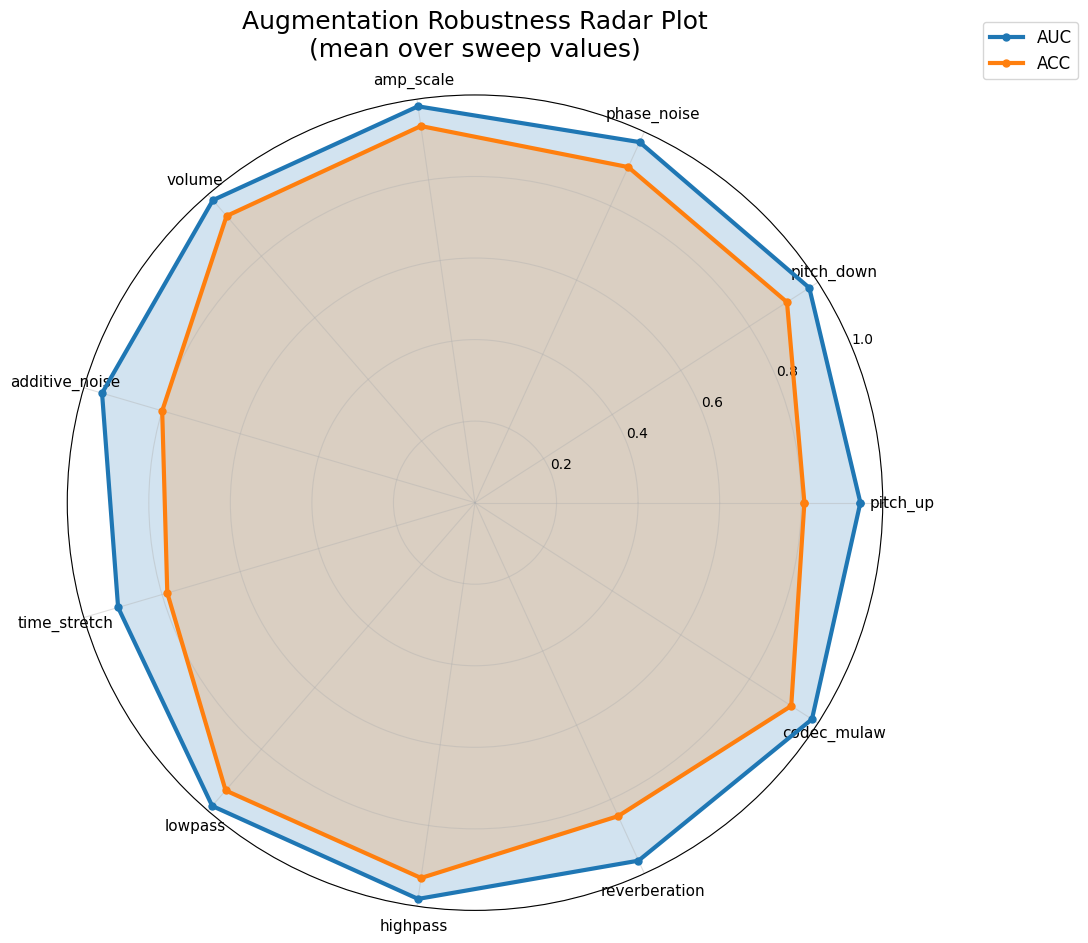

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "recovered.csv"

# ── Load data ────────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)

metric_cols = ["val_acc", "val_auc"]
for col in metric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["aug_name"]).copy()
df = df[df[metric_cols].notna().any(axis=1)].copy()

# ── Aggregate by augmentation type ──────────────────────────────────────────
agg = df.groupby("aug_name", as_index=False)[metric_cols].mean()

plot_metrics = [
    ("val_auc", "AUC"),
    ("val_acc", "ACC"),
]

preferred_order = [
    "pitch_up", "pitch_down", "phase_noise", "amp_scale", "volume",
    "additive_noise", "time_stretch", "lowpass", "highpass",
    "reverberation", "codec_mulaw",
]

present   = [a for a in preferred_order if a in agg["aug_name"].values]
remaining = [a for a in agg["aug_name"].values if a not in present]
aug_order = present + sorted(remaining)

agg = agg.set_index("aug_name").loc[aug_order].reset_index()

# ── Radar setup ──────────────────────────────────────────────────────────────
labels  = agg["aug_name"].tolist()
N       = len(labels)
angles  = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(11, 11), subplot_kw=dict(polar=True))

colors = {"AUC": "#1f77b4", "ACC": "#ff7f0e"}

for col, display_name in plot_metrics:
    values  = agg[col].fillna(0).tolist()
    values += values[:1]
    c = colors[display_name]
    ax.plot(angles, values, linewidth=3, marker="o", markersize=5, color=c, label=display_name)
    ax.fill(angles, values, color=c, alpha=0.20)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=10)
ax.set_title("Augmentation Robustness Radar Plot\n(mean over sweep values)", pad=28, fontsize=18)
ax.grid(True, alpha=0.4)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.10), fontsize=12)

plt.tight_layout()
plt.savefig("radar_plot.png", dpi=150, bbox_inches="tight")
plt.show()